# Assignment 5 — Nonlinear Systems

#### Name: Bammidi Pragati Rao
#### Roll Number: 252CD005

---

## Task 1: Newton’s Method

### Question

Implement Newton’s Method from scratch to solve a nonlinear system:

- Use analytical Jacobian  
- Solve $J(x_k)\Delta x = -F(x_k)$  
- Update $x_{k+1} = x_k + \Delta x$  
- Stop when $||F(x)|| < 10^{-6}$  
- Print iteration table  

---

### Theory

Newton’s method is derived from first-order Taylor expansion:

$$
F(x + \Delta x) \approx F(x) + J(x)\Delta x
$$

Setting $F(x + \Delta x) = 0$:

$$
J(x_k)\Delta x = -F(x_k)
$$

Update rule:

$$
x_{k+1} = x_k + \Delta x
$$

---

We are given the nonlinear system:

$$f_1(x_1, x_2, x_3) = 3x_1 - \cos(x_2x_3) - \frac{1}{2}$$

$$f_2(x_1, x_2, x_3) = x_1^2 - 81(x_2 + 0.1)^2 + \sin(x_3) + 1.06$$

$$f_3(x_1, x_2, x_3) = e^{-x_1x_2} + 20x_3 + \frac{10\pi - 3}{3}$$

We compute the Jacobian analytically and solve iteratively using linearization.

### Jacobian Matrix
$$J(x) = \begin{bmatrix} 3 & x_3 \sin(x_2 x_3) & x_2 \sin(x_2 x_3) \\ 2x_1 & -162(x_2+0.1) & \cos(x_3) \\ -x_2 e^{-x_1 x_2} & -x_1 e^{-x_1 x_2} & 20 \end{bmatrix}$$

### Insight

- Converts nonlinear system → linear system  
- Requires Jacobian matrix  
- Converges **quadratically**

In [24]:
import numpy as np
import math
import matplotlib.pyplot as plt

def F(x):
    x1,x2,x3=x
    return np.array([
        3*x1-math.cos(x2*x3)-0.5,
        x1**2-81*(x2+0.1)**2+math.sin(x3)+1.06,
        math.exp(-x1*x2)+20*x3+(10*math.pi-3)/3
    ])

def J(x):
    x1,x2,x3=x
    return np.array([
        [3,x3*math.sin(x2*x3),x2*math.sin(x2*x3)],
        [2*x1,-162*(x2+0.1),math.cos(x3)],
        [-x2*math.exp(-x1*x2),-x1*math.exp(-x1*x2),20]
    ])

def newton(x0):
    x=x0.copy()
    rows=[]
    for k in range(50):
        Fx=F(x)
        norm=np.linalg.norm(Fx)
        rows.append((k,x[0],x[1],x[2],norm))
        if norm<1e-6: break
        x=x+np.linalg.solve(J(x),-Fx)
    
    print("\nNewton Iteration Table")
    print("k          x1           x2           x3       ||F||")
    for r in rows:
        print(f"{r[0]:<3d} {r[1]:>12.6f} {r[2]:>12.6f} {r[3]:>12.6f} {r[4]:>12.6e}")
    
    return x,rows

x0=np.array([0.1,0.1,-0.1])
xn, hist_newton=newton(x0)


Newton Iteration Table
k          x1           x2           x3       ||F||
0       0.100000     0.100000    -0.100000 8.842957e+00
1       0.499870     0.019467    -0.521520 3.458607e-01
2       0.500014     0.001589    -0.523557 2.588921e-02
3       0.500000     0.000012    -0.523598 2.012231e-04
4       0.500000     0.000000    -0.523599 1.254311e-08


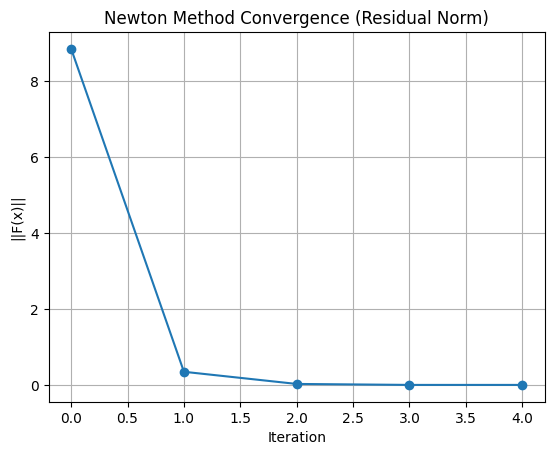

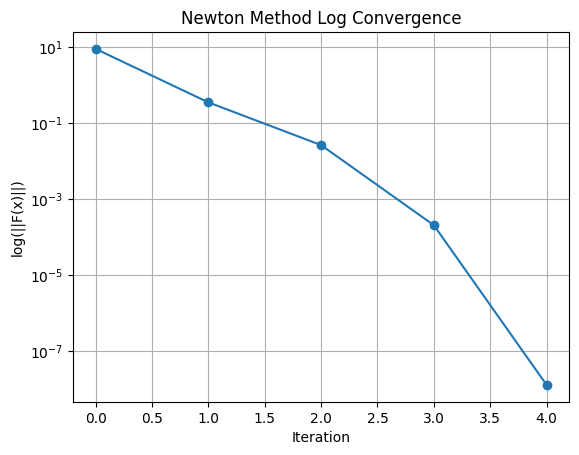

In [25]:
# --- Newton Convergence Plots ---

# Extract data
iters_n = [r[0] for r in hist_newton]
norms_n = [r[4] for r in hist_newton]

# Plot 1: Residual norm vs iteration
plt.figure()
plt.plot(iters_n, norms_n, marker='o')
plt.xlabel("Iteration")
plt.ylabel("||F(x)||")
plt.title("Newton Method Convergence (Residual Norm)")
plt.grid()
plt.savefig("newton_residual.png")
plt.show()

# Plot 2: Log-scale convergence
plt.figure()
plt.semilogy(iters_n, norms_n, marker='o')
plt.xlabel("Iteration")
plt.ylabel("log(||F(x)||)")
plt.title("Newton Method Log Convergence")
plt.grid()
plt.savefig("newton_log_convergence.png")
plt.show()

---

## Task 2: Broyden’s Method

### Question

Implement Broyden’s method using:

$$
B_{k+1} = B_k + \frac{(\Delta f - B_k \Delta x)\Delta x^T}{\Delta x^T \Delta x}
$$

---

### Theory

- Avoids recomputing Jacobian  
- Uses rank-1 update  
- Efficient for large systems  

---

### Insight

- Slower than Newton  
- Reduces computational cost  

In [26]:
def broyden(x0):
    x=x0.copy()
    B=J(x)
    rows=[]
    
    for k in range(50):
        Fx=F(x)
        norm=np.linalg.norm(Fx)
        rows.append((k,x[0],x[1],x[2],norm))
        
        if norm<1e-6: break
        
        dx=np.linalg.solve(B,-Fx)
        x_new=x+dx
        
        y=F(x_new)-Fx
        B=B+np.outer((y-B@dx),dx)/(dx@dx)
        
        x=x_new
    
    print("\nBroyden Iteration Table")
    print("k          x1           x2           x3       ||F||")
    for r in rows:
        print(f"{r[0]:<3d} {r[1]:>12.6f} {r[2]:>12.6f} {r[3]:>12.6f} {r[4]:>12.6e}")
    
    return x,rows

xb, hist_broyden=broyden(x0)


Broyden Iteration Table
k          x1           x2           x3       ||F||
0       0.100000     0.100000    -0.100000 8.842957e+00
1       0.499870     0.019467    -0.521520 3.458607e-01
2       0.499986     0.008738    -0.523175 1.474413e-01
3       0.500007     0.000867    -0.523572 1.408160e-02
4       0.500000     0.000040    -0.523598 6.392158e-04
5       0.500000     0.000000    -0.523599 3.129087e-06
6       0.500000     0.000000    -0.523599 1.869024e-11


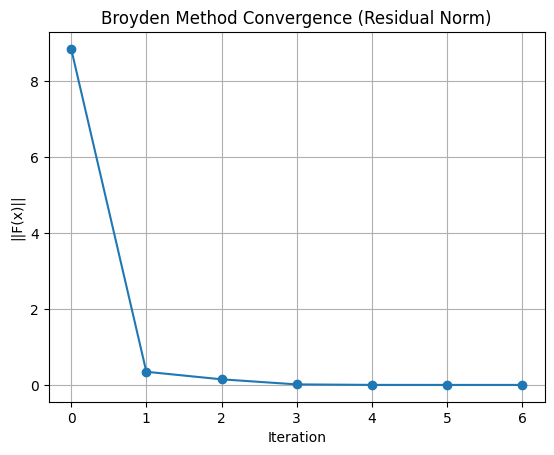

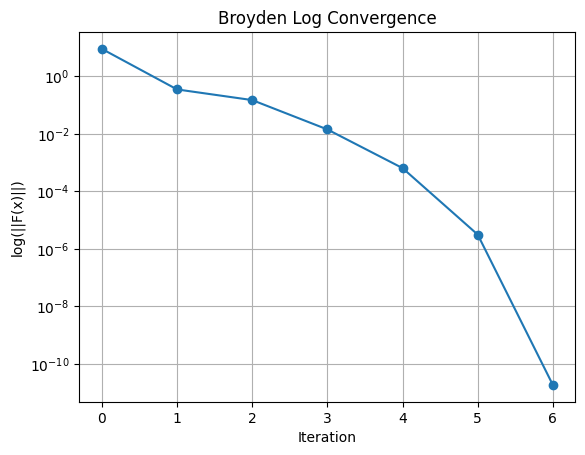

In [27]:
# --- Broyden Convergence Plots ---

iters_b = [r[0] for r in hist_broyden]
norms_b = [r[4] for r in hist_broyden]

# Plot 1: Residual norm
plt.figure()
plt.plot(iters_b, norms_b, marker='o')
plt.xlabel("Iteration")
plt.ylabel("||F(x)||")
plt.title("Broyden Method Convergence (Residual Norm)")
plt.grid()
plt.savefig("broyden_residual.png")
plt.show()

# Plot 2: Log convergence
plt.figure()
plt.semilogy(iters_b, norms_b, marker='o')
plt.xlabel("Iteration")
plt.ylabel("log(||F(x)||)")
plt.title("Broyden Log Convergence")
plt.grid()
plt.savefig("broyden_log_convergence.png")
plt.show()

---

## Task 3: R² Comparison

### Question

Compute:

$$
R^2 = 1 - \frac{||F(x_k)||^2}{||F(x_0)||^2}
$$

---

### Explanation

- Measures convergence quality  
- $R^2 \to 1$ indicates convergence  

In [28]:
F0=np.linalg.norm(F(x0))**2

def compute_r2(hist):
    norms=[]
    r2=[]
    for k,x1,x2,x3,n in hist:
        norms.append(n)
        r2.append(1-(n**2/F0))
    return norms,r2

norm_n,r2_n=compute_r2(hist_newton)
norm_b,r2_b=compute_r2(hist_broyden)

print("\nR² Comparison Table")
print("k     ||F||_Newton     R2_Newton  ||F||_Broyden    R2_Broyden")

for i in range(max(len(norm_n),len(norm_b))):
    print(f"{i:<3d} "
          f"{(norm_n[i] if i<len(norm_n) else 0):>14.6e} "
          f"{(r2_n[i] if i<len(r2_n) else 0):>12.6f} "
          f"{(norm_b[i] if i<len(norm_b) else 0):>14.6e} "
          f"{(r2_b[i] if i<len(r2_b) else 0):>12.6f}")



R² Comparison Table
k     ||F||_Newton     R2_Newton  ||F||_Broyden    R2_Broyden
0     8.842957e+00     0.000000   8.842957e+00     0.000000
1     3.458607e-01     0.998470   3.458607e-01     0.998470
2     2.588921e-02     0.999991   1.474413e-01     0.999722
3     2.012231e-04     1.000000   1.408160e-02     0.999997
4     1.254311e-08     1.000000   6.392158e-04     1.000000
5     0.000000e+00     0.000000   3.129087e-06     1.000000
6     0.000000e+00     0.000000   1.869024e-11     1.000000


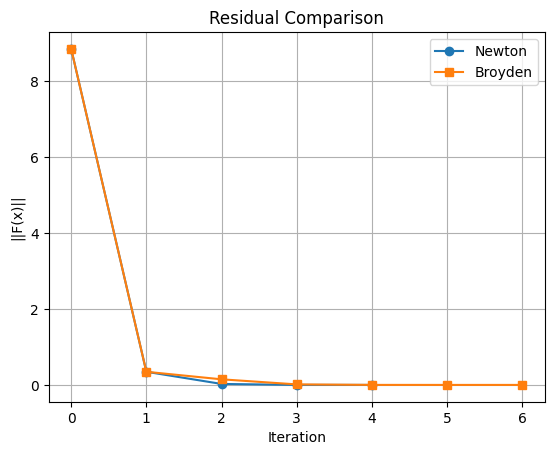

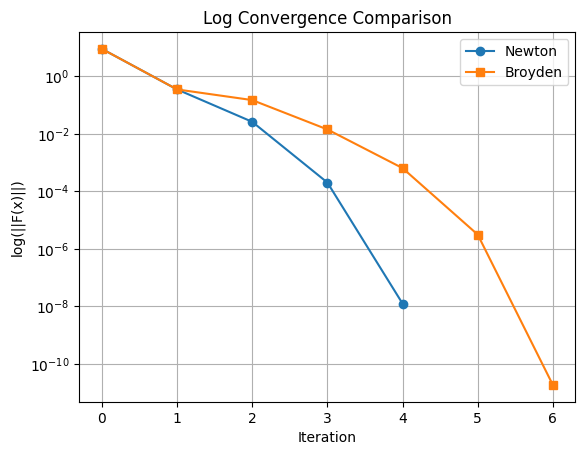

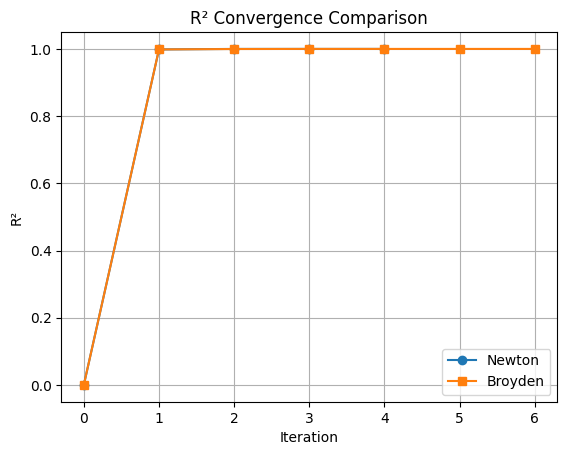

In [29]:
# --- Combined Comparison Plots ---

# Plot 1: Residual comparison
plt.figure()
plt.plot(norm_n, marker='o', label="Newton")
plt.plot(norm_b, marker='s', label="Broyden")
plt.xlabel("Iteration")
plt.ylabel("||F(x)||")
plt.title("Residual Comparison")
plt.legend()
plt.grid()
plt.savefig("residual_comparison.png")
plt.show()

# Plot 2: Log comparison
plt.figure()
plt.semilogy(norm_n, marker='o', label="Newton")
plt.semilogy(norm_b, marker='s', label="Broyden")
plt.xlabel("Iteration")
plt.ylabel("log(||F(x)||)")
plt.title("Log Convergence Comparison")
plt.legend()
plt.grid()
plt.savefig("log_comparison.png")
plt.show()

# Plot 3: R² comparison (already required)
plt.figure()
plt.plot(r2_n, marker='o', label="Newton")
plt.plot(r2_b, marker='s', label="Broyden")
plt.xlabel("Iteration")
plt.ylabel("R²")
plt.title("R² Convergence Comparison")
plt.legend()
plt.grid()
plt.savefig("convergence_rsquare.png")
plt.show()

---

## Task 4: Analysis

### Observations

- Newton converges faster  
- Broyden requires more iterations  

---

### Comparison

| Method | Convergence |
|--------|------------|
| Newton | Quadratic  |
| Broyden | Superlinear |

---

### Conclusion

- Newton is preferred when Jacobian is easy  
- Broyden is useful when Jacobian is expensive

### 1. Error Decay Comparison (||xₖ − x*||)

This plot shows how quickly each method approaches the true solution \( x^* \).

#### Observations:
- The **Newton method** exhibits a very steep decline in error.
- The error drops rapidly after just a few iterations.
- The **Broyden method** shows a more gradual decrease in error.

#### Interpretation:
- Newton’s method has **quadratic convergence**, meaning the error roughly squares at each step once near the solution.
- Broyden’s method has **superlinear convergence**, which is slower than quadratic but still faster than linear methods.

#### Conclusion:
- Newton is significantly more accurate in fewer iterations.
- Broyden is slower but still converges reliably without exact Jacobian computation.

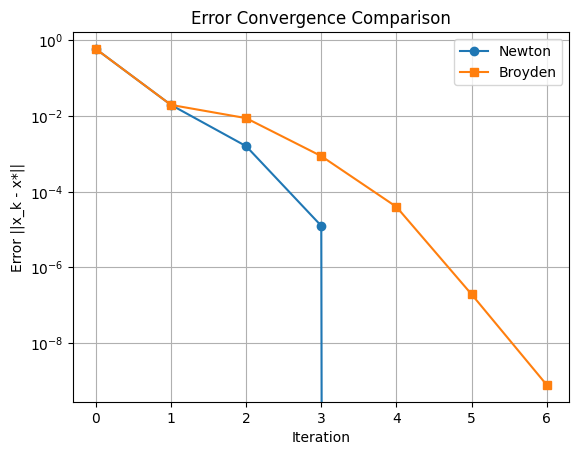

In [30]:
# --- Error Decay Plot ---

# Approximate final solution as last Newton value
x_star = xn

def error_norm(hist):
    return [np.linalg.norm(np.array([r[1],r[2],r[3]]) - x_star) for r in hist]

err_n = error_norm(hist_newton)
err_b = error_norm(hist_broyden)

plt.figure()
plt.semilogy(err_n, marker='o', label="Newton")
plt.semilogy(err_b, marker='s', label="Broyden")
plt.xlabel("Iteration")
plt.ylabel("Error ||x_k - x*||")
plt.title("Error Convergence Comparison")
plt.legend()
plt.grid()
plt.savefig("error_comparison.png")
plt.show()

### 2. Convergence Rate Comparison

This plot shows the ratio:

\[
\frac{||F(x_{k+1})||}{||F(x_k)||}
\]

#### Observations:
- For **Newton’s method**, the ratio drops rapidly toward zero.
- For **Broyden’s method**, the decrease is slower and less consistent.

#### Interpretation:
- A rapidly decreasing ratio indicates **faster convergence speed**.
- Newton’s sharp drop confirms **quadratic convergence behavior**.
- Broyden’s smoother decline reflects **superlinear convergence**.

#### Conclusion:
- Newton achieves faster reduction in residual per iteration.
- Broyden is less aggressive but computationally cheaper per step.

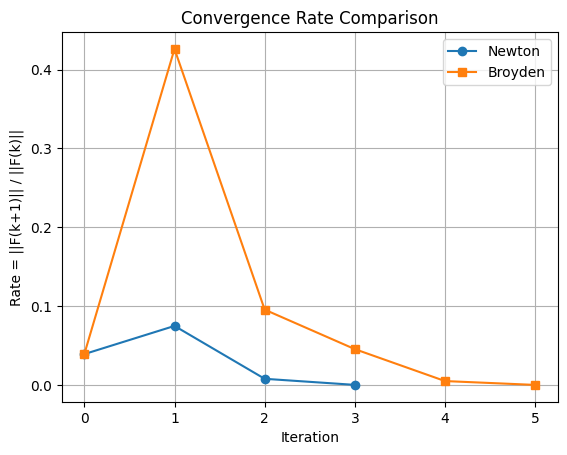

In [31]:
# --- Convergence Rate Plot ---

def rate(norms):
    return [norms[i+1]/norms[i] for i in range(len(norms)-1)]

rate_n = rate(norm_n)
rate_b = rate(norm_b)

plt.figure()
plt.plot(rate_n, marker='o', label="Newton")
plt.plot(rate_b, marker='s', label="Broyden")
plt.xlabel("Iteration")
plt.ylabel("Rate = ||F(k+1)|| / ||F(k)||")
plt.title("Convergence Rate Comparison")
plt.legend()
plt.grid()
plt.savefig("rate_comparison.png")
plt.show()

### 3. Iteration Count Comparison

This bar chart compares the total number of iterations required to reach convergence.

#### Observations:
- Newton requires **fewer iterations** to converge.
- Broyden requires **more iterations** for the same tolerance.

#### Interpretation:
- Newton benefits from exact Jacobian information, leading to faster convergence.
- Broyden trades off accuracy for efficiency by approximating the Jacobian.

#### Conclusion:
- Newton is more efficient in terms of iteration count.
- Broyden may still be preferable when Jacobian computation is expensive in large systems.

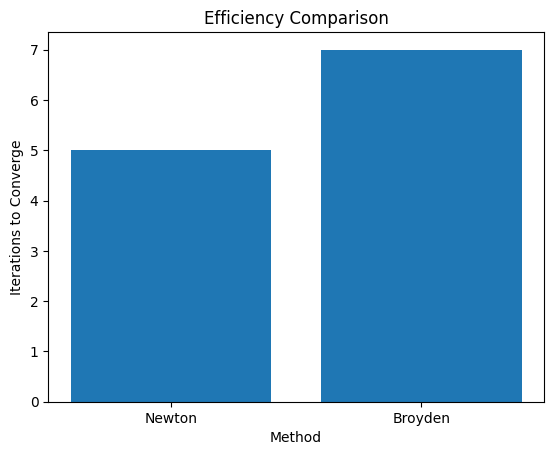

In [32]:
# --- Iteration Count Comparison ---

methods = ["Newton", "Broyden"]
iterations = [len(hist_newton), len(hist_broyden)]

plt.figure()
plt.bar(methods, iterations)
plt.xlabel("Method")
plt.ylabel("Iterations to Converge")
plt.title("Efficiency Comparison")
plt.savefig("iteration_comparison.png")
plt.show()

### 4. 3D Trajectory of Iterates

This plot visualizes how each method moves in the solution space \((x_1, x_2, x_3)\).

#### Observations:
- Newton’s path is **direct and rapidly converging** toward the solution.
- Broyden’s path is **less direct**, often taking a more curved route.

#### Interpretation:
- Newton uses exact curvature information (Jacobian), allowing it to move optimally.
- Broyden gradually improves its approximation, leading to a less efficient path.

#### Conclusion:
- Newton follows a more optimal trajectory.
- Broyden explores more before converging, reflecting its approximation nature.

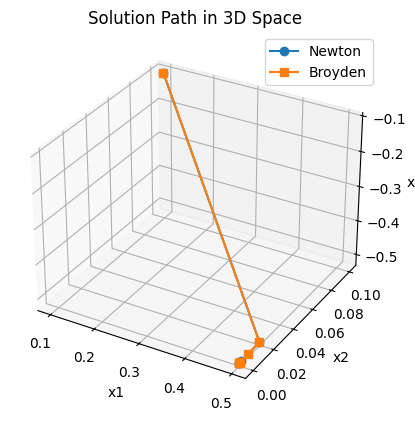

In [33]:
# --- 3D Trajectory Plot ---

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

xn_path = np.array([[r[1],r[2],r[3]] for r in hist_newton])
xb_path = np.array([[r[1],r[2],r[3]] for r in hist_broyden])

ax.plot(xn_path[:,0], xn_path[:,1], xn_path[:,2], marker='o', label="Newton")
ax.plot(xb_path[:,0], xb_path[:,1], xb_path[:,2], marker='s', label="Broyden")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Solution Path in 3D Space")
ax.legend()

plt.savefig("trajectory_3d.png")
plt.show()

## Overall Comparative Summary

| Aspect                | Newton Method        | Broyden Method        |
|---------------------|---------------------|----------------------|
| Convergence Speed    | Very Fast (Quadratic) | Moderate (Superlinear) |
| Iterations Required  | Fewer               | More                 |
| Computational Cost   | High (Jacobian)     | Lower (Approximation)|
| Path Efficiency      | Direct              | Indirect             |
| Accuracy             | High                | Slightly Lower       |

### ✅ Final Insight

Newton’s method is ideal when:
- Jacobian is easy to compute  
- High accuracy is required  

Broyden’s method is ideal when:
- Jacobian computation is expensive  
- System dimension is large  

This comparison highlights the fundamental trade-off between **accuracy and computational efficiency**.